In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.spectograms import SpectogramConfig
from src.model_trainer import ModelTrainer
from src.image_preprocessor import ImagePreprocessor
from src.gradcam import GradCam
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from IPython.display import Image, display

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
preprocessor = ImagePreprocessor()
data = preprocessor.load_data_from_directory("../src/data/images_test/images_spectograms")

In [7]:
model_name = "MobileNetV3Large" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"../models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "MobileNetV3Large_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │       640,987 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,637,339 (13.88 MB)

 Trainable params: 3,612,939 (13.78 MB)

 Non-trainable params: 24,400 (95.31 KB)

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 346 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Specie: Acropternis orthonyx



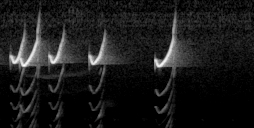

In [45]:
random = np.random.randint(0, data.shape[0])
print(f'Specie: {data.label[random]}\n')
img_path = data['image_path'][random]
display(Image(img_path))

In [46]:
gradcam = GradCam(model, model_name=model_name)

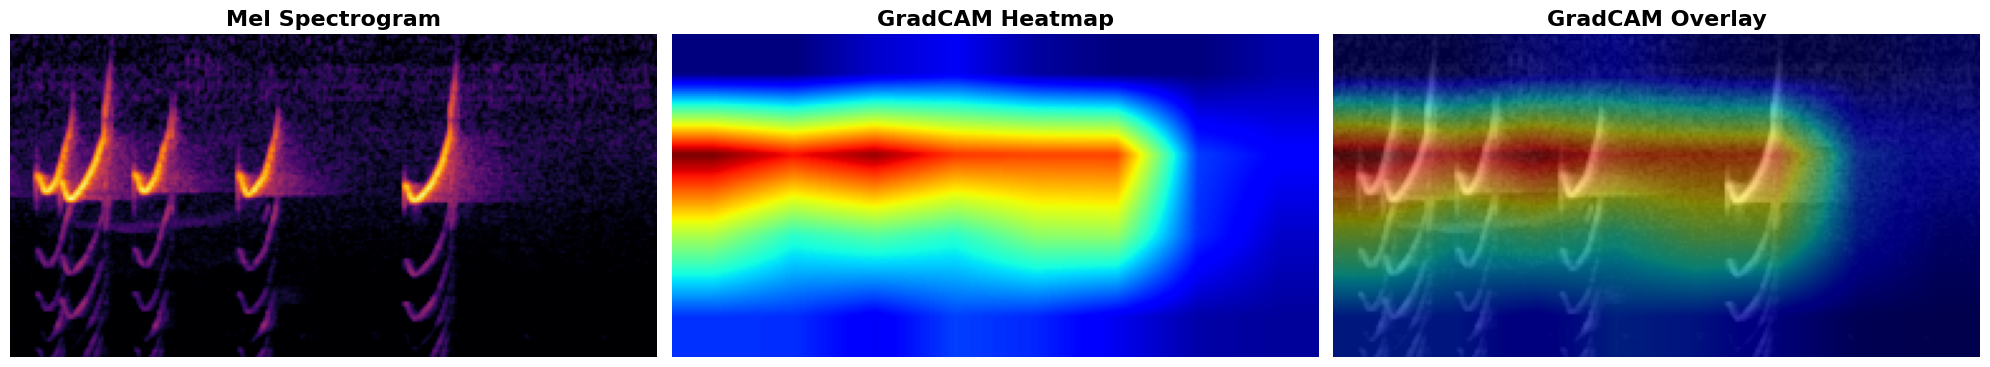

In [47]:
heatmap, original_img, class_output = gradcam.generate_gradcam(img_path)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Imagen original
if len(original_img.shape) == 3:
    original_gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
    axes[0].imshow(original_gray, cmap='inferno')
else:
    axes[0].imshow(original_img, cmap='inferno')
axes[0].set_title('Mel Spectrogram', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Mapa de calor
axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title('GradCAM Heatmap', fontsize=16, fontweight='bold')
axes[1].axis('off')

# Superposición
axes[2].imshow(original_img)
axes[2].imshow(heatmap, alpha=0.5, cmap='jet')
axes[2].set_title('GradCAM Overlay', fontsize=16, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [48]:
# 🔍 ANÁLISIS AUTOMÁTICO DEL GRADCAM PARA ESPECTROGRAMAS DE MEL

print("🔍 ANÁLISIS DEL GRADCAM:")
print(f"📋 Especie: {data.label[random]}")
print(f"🎯 Confianza del modelo: {np.max(class_output):.3f}")

# Encontrar zonas de máxima activación
max_activation = np.max(heatmap)
threshold = max_activation * 0.7  # 70% del máximo
important_regions = heatmap > threshold

# Análisis temporal (promedio por columna de tiempo)
temporal_importance = np.mean(heatmap, axis=0)
peak_time_idx = np.argmax(temporal_importance)
total_time_steps = len(temporal_importance)
peak_time_percent = (peak_time_idx / total_time_steps) * 100

# Análisis frecuencial (promedio por fila de frecuencia)
freq_importance = np.mean(heatmap, axis=1)
peak_freq_idx = np.argmax(freq_importance)
total_freq_bins = len(freq_importance)
# Frecuencias mel van de grave (abajo) a agudo (arriba)
peak_freq_percent = ((total_freq_bins - peak_freq_idx) / total_freq_bins) * 100

print(f"\n⏰ ANÁLISIS TEMPORAL:")
print(f"   Momento más importante: {peak_time_percent:.1f}% del audio")
if peak_time_percent < 33:
    print("   └── El modelo se enfoca en el INICIO del canto")
elif peak_time_percent < 66:
    print("   └── El modelo se enfoca en el MEDIO del canto")
else:
    print("   └── El modelo se enfoca en el FINAL del canto")

print(f"\n🎵 ANÁLISIS FRECUENCIAL:")
print(f"   Frecuencia más importante: {peak_freq_percent:.1f}% del rango")
if peak_freq_percent < 33:
    print("   └── Se enfoca en frecuencias GRAVES (tonos bajos)")
elif peak_freq_percent < 66:
    print("   └── Se enfoca en frecuencias MEDIAS")
else:
    print("   └── Se enfoca en frecuencias AGUDAS (tonos altos)")

# Porcentaje de imagen considerado importante
important_pixels = np.sum(important_regions)
total_pixels = heatmap.size
importance_coverage = (important_pixels / total_pixels) * 100

print(f"\n📊 SELECTIVIDAD DEL MODELO:")
print(f"   Cobertura de zonas importantes: {importance_coverage:.1f}% de la imagen")
if importance_coverage < 10:
    print("   └── Modelo MUY SELECTIVO - se enfoca en detalles específicos del canto")
elif importance_coverage < 30:
    print("   └── Modelo SELECTIVO - identifica patrones claros y distintivos")
else:
    print("   └── Modelo GENERAL - usa información distribuida en el espectrograma")

print(f"\n🔥 INTERPRETACIÓN:")
print("   • Las zonas ROJAS/AMARILLAS son las características más importantes")
print("   • Las zonas AZULES/VERDES tienen menor influencia en la clasificación")
print("   • Las zonas NEGRAS son ignoradas por el modelo")
print("   • Busca patrones como: notas específicas, trinos, llamadas, o armónicos")


🔍 ANÁLISIS DEL GRADCAM:
📋 Especie: Acropternis orthonyx
🎯 Confianza del modelo: 6.138

⏰ ANÁLISIS TEMPORAL:
   Momento más importante: 0.0% del audio
   └── El modelo se enfoca en el INICIO del canto

🎵 ANÁLISIS FRECUENCIAL:
   Frecuencia más importante: 62.5% del rango
   └── Se enfoca en frecuencias MEDIAS

📊 SELECTIVIDAD DEL MODELO:
   Cobertura de zonas importantes: 12.4% de la imagen
   └── Modelo SELECTIVO - identifica patrones claros y distintivos

🔥 INTERPRETACIÓN:
   • Las zonas ROJAS/AMARILLAS son las características más importantes
   • Las zonas AZULES/VERDES tienen menor influencia en la clasificación
   • Las zonas NEGRAS son ignoradas por el modelo
   • Busca patrones como: notas específicas, trinos, llamadas, o armónicos


In [ ]:
# 🎵 GUÍA DE INTERPRETACIÓN: PATRONES COMUNES EN GRADCAM DE ESPECTROGRAMAS

print("🎵 PATRONES COMUNES EN GRADCAM DE CANTOS DE AVES:")
print("\n📊 TIPOS DE ACTIVACIÓN Y SU SIGNIFICADO:")

print("\n1️⃣ FRANJAS HORIZONTALES ROJAS:")
print("   • Significado: Frecuencias específicas constantes")
print("   • Ejemplo: Tonos puros, silbidos, notas sostenidas")
print("   • Interpretación: El modelo detecta la 'firma frecuencial' de la especie")

print("\n2️⃣ BLOQUES ROJOS CONCENTRADOS:")
print("   • Significado: Sílabas o notas específicas del canto")
print("   • Ejemplo: 'Chip', 'tweet', llamadas cortas")
print("   • Interpretación: Elementos distintivos del vocabulario del ave")

print("\n3️⃣ FRANJAS VERTICALES:")
print("   • Significado: Momentos específicos importantes")
print("   • Ejemplo: Inicio de canto, pausas características")
print("   • Interpretación: Timing crucial para la identificación")

print("\n4️⃣ GRADIENTES DIAGONALES:")
print("   • Significado: Barridos de frecuencia (glissandos)")
print("   • Ejemplo: Trinos ascendentes/descendentes")
print("   • Interpretación: Patrones melódicos únicos de la especie")

print("\n5️⃣ MÚLTIPLES FRANJAS PARALELAS:")
print("   • Significado: Armónicos o series de frecuencias relacionadas")
print("   • Ejemplo: Tonos fundamentales + armónicos superiores")
print("   • Interpretación: Estructura tímbrica característica")

print("\n6️⃣ ACTIVACIÓN DISPERSA:")
print("   • Significado: Múltiples características distribuidas")
print("   • Ejemplo: Cantos complejos con varios elementos")
print("   • Interpretación: El modelo usa información combinada")

print("\n⚠️  SEÑALES DE ALERTA:")
print("   🔴 Activación en zonas de ruido → Posible sobreajuste")
print("   🔴 Muy poca activación → Modelo poco confiado")
print("   🔴 Activación solo en bordes → Artefactos de procesamiento")

print("\n✅ BUENAS SEÑALES:")
print("   ✅ Activación en zonas del canto principal")
print("   ✅ Patrones coherentes con conocimiento ornitológico")
print("   ✅ Activación selectiva (no toda la imagen)")
print("   ✅ Correspondencia con elementos distintivos del audio")


In [ ]:
# 📋 FUNCIÓN PARA GENERAR REPORTES DETALLADOS DE GRADCAM

def generar_reporte_gradcam(heatmap, species_name, confidence, save_report=False):
    """
    Genera un reporte detallado del análisis GradCAM para documentación científica.

    Parameters:
    -----------
    heatmap : np.ndarray
        Mapa de calor generado por GradCAM
    species_name : str
        Nombre de la especie clasificada
    confidence : float
        Confianza del modelo en la clasificación
    save_report : bool
        Si guardar el reporte en un archivo txt
    """

    from datetime import datetime

    # Análisis cuantitativo
    max_activation = np.max(heatmap)
    threshold_high = max_activation * 0.8
    threshold_medium = max_activation * 0.5

    high_importance = np.sum(heatmap > threshold_high)
    medium_importance = np.sum(heatmap > threshold_medium)
    total_pixels = heatmap.size

    # Análisis temporal y frecuencial
    temporal_profile = np.mean(heatmap, axis=0)
    freq_profile = np.mean(heatmap, axis=1)

    # Estadísticas
    temporal_peak = np.argmax(temporal_profile) / len(temporal_profile) * 100
    freq_peak = (len(freq_profile) - np.argmax(freq_profile)) / len(freq_profile) * 100

    # Métricas de dispersión
    temporal_std = np.std(temporal_profile)
    freq_std = np.std(freq_profile)

    # Generar reporte
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    report = f"""
🔬 REPORTE CIENTÍFICO DE ANÁLISIS GRADCAM
{'='*50}

📊 INFORMACIÓN GENERAL:
   • Especie: {species_name}
   • Fecha de análisis: {timestamp}
   • Confianza del modelo: {confidence:.4f}
   • Arquitectura: {model_name}

📈 ANÁLISIS CUANTITATIVO:
   • Activación máxima: {max_activation:.4f}
   • Píxeles alta importancia (>80%): {high_importance:,} ({high_importance/total_pixels*100:.2f}%)
   • Píxeles media importancia (>50%): {medium_importance:,} ({medium_importance/total_pixels*100:.2f}%)
   • Selectividad del modelo: {'Alta' if high_importance/total_pixels < 0.1 else 'Media' if high_importance/total_pixels < 0.3 else 'Baja'}

⏰ ANÁLISIS TEMPORAL:
   • Pico de importancia: {temporal_peak:.1f}% del audio
   • Fase principal: {'Inicio' if temporal_peak < 33 else 'Medio' if temporal_peak < 66 else 'Final'}
   • Dispersión temporal: {temporal_std:.4f}
   • Distribución: {'Concentrada' if temporal_std < 0.1 else 'Distribuida'}

🎵 ANÁLISIS FRECUENCIAL:
   • Rango frecuencial principal: {freq_peak:.1f}% del espectro
   • Tipo de frecuencias: {'Graves' if freq_peak < 33 else 'Medias' if freq_peak < 66 else 'Agudas'}
   • Dispersión frecuencial: {freq_std:.4f}
   • Complejidad espectral: {'Simple' if freq_std < 0.1 else 'Compleja'}

🔍 INTERPRETACIÓN ORNITOLÓGICA:
   • El modelo se enfoca en {'características temporales específicas' if temporal_std < freq_std else 'patrones frecuenciales distintivos'}
   • Estrategia de clasificación: {'Selectiva' if high_importance/total_pixels < 0.2 else 'Integral'}
   • Confiabilidad: {'Alta' if confidence > 0.9 else 'Media' if confidence > 0.7 else 'Baja'}

💡 RECOMENDACIONES:
   • {'Verificar coherencia con literatura ornitológica' if confidence > 0.9 else 'Considerar más datos de entrenamiento'}
   • {'Análisis validado por experto recomendado' if high_importance/total_pixels < 0.1 else 'Patrón amplio detectado - revisar calidad de audio'}
"""

    print(report)

    if save_report:
        filename = f"gradcam_report_{species_name.replace(' ', '_')}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(report)
        print(f"\n📄 Reporte guardado en: {filename}")

    return report

# Ejecutar el reporte para la imagen actual
reporte = generar_reporte_gradcam(heatmap, data.label[random], np.max(class_output), save_report=False)


In [ ]:
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {layer.name}")

In [ ]:
for i, layer in enumerate(model.get_layer("MobileNetV3Large").layers):
    print(f"Layer {i}: {layer.name}")